In [10]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



Project root added to sys.path: d:\charitha\projects\STN-GPe_spiking\light_house_DBS_decision_making


In [11]:
# ENV params
NUM_ARMS = 4
MEAN_REWARD = np.array([40,40,60,80])
REW_STD = np.array([4,4,4,4])
SCALING_FACTOR = 100

# Training params
TRAILS = 300
EPOCHS = 25
BINS = 10
LR = 1e-1 


LAMBDA_DECAY = 0.9836
THETA = 50
DIFFUSIVE_NOISE_MEAN = 0
DIFFUSIVE_NOISE_STD = 2.8

In [48]:
var = 0.3 #0.25
ARM_MONITOR = defaultdict(dict)
NUM_ARM_PICKS_MONITOR = defaultdict(dict)
DP_MONITOR = defaultdict(dict)
IP_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)
ARM_TRACKER = defaultdict(dict)

In [49]:
env = RestlessBanditsEnv(num_arms=NUM_ARMS, 
                         mean_reward=MEAN_REWARD/SCALING_FACTOR, 
                         std = REW_STD/SCALING_FACTOR,
                         lambda_decay = LAMBDA_DECAY, 
                         theta = THETA/SCALING_FACTOR, 
                         diffusive_noise_std = DIFFUSIVE_NOISE_STD/SCALING_FACTOR, 
                         diffusive_noise_mean = DIFFUSIVE_NOISE_MEAN/SCALING_FACTOR)
print(env.arms)

{0: (0.4, 0.04), 1: (0.4, 0.04), 2: (0.6, 0.04), 3: (0.8, 0.04)}


In [50]:
reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, arm_tracker_full= train(env, 
                                                      trails = TRAILS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = None, 
                                                      d1_amp=1,
                                                      d2_amp=0.01, 
                                                      gpi_threshold=0.3,
                                                      max_gpi_iters=50,
                                                      del_lim=None, train_IP = False, 
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = var,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0, 
                                                      track_arms = True)


  0%|          | 0/25 [00:00<?, ?it/s]

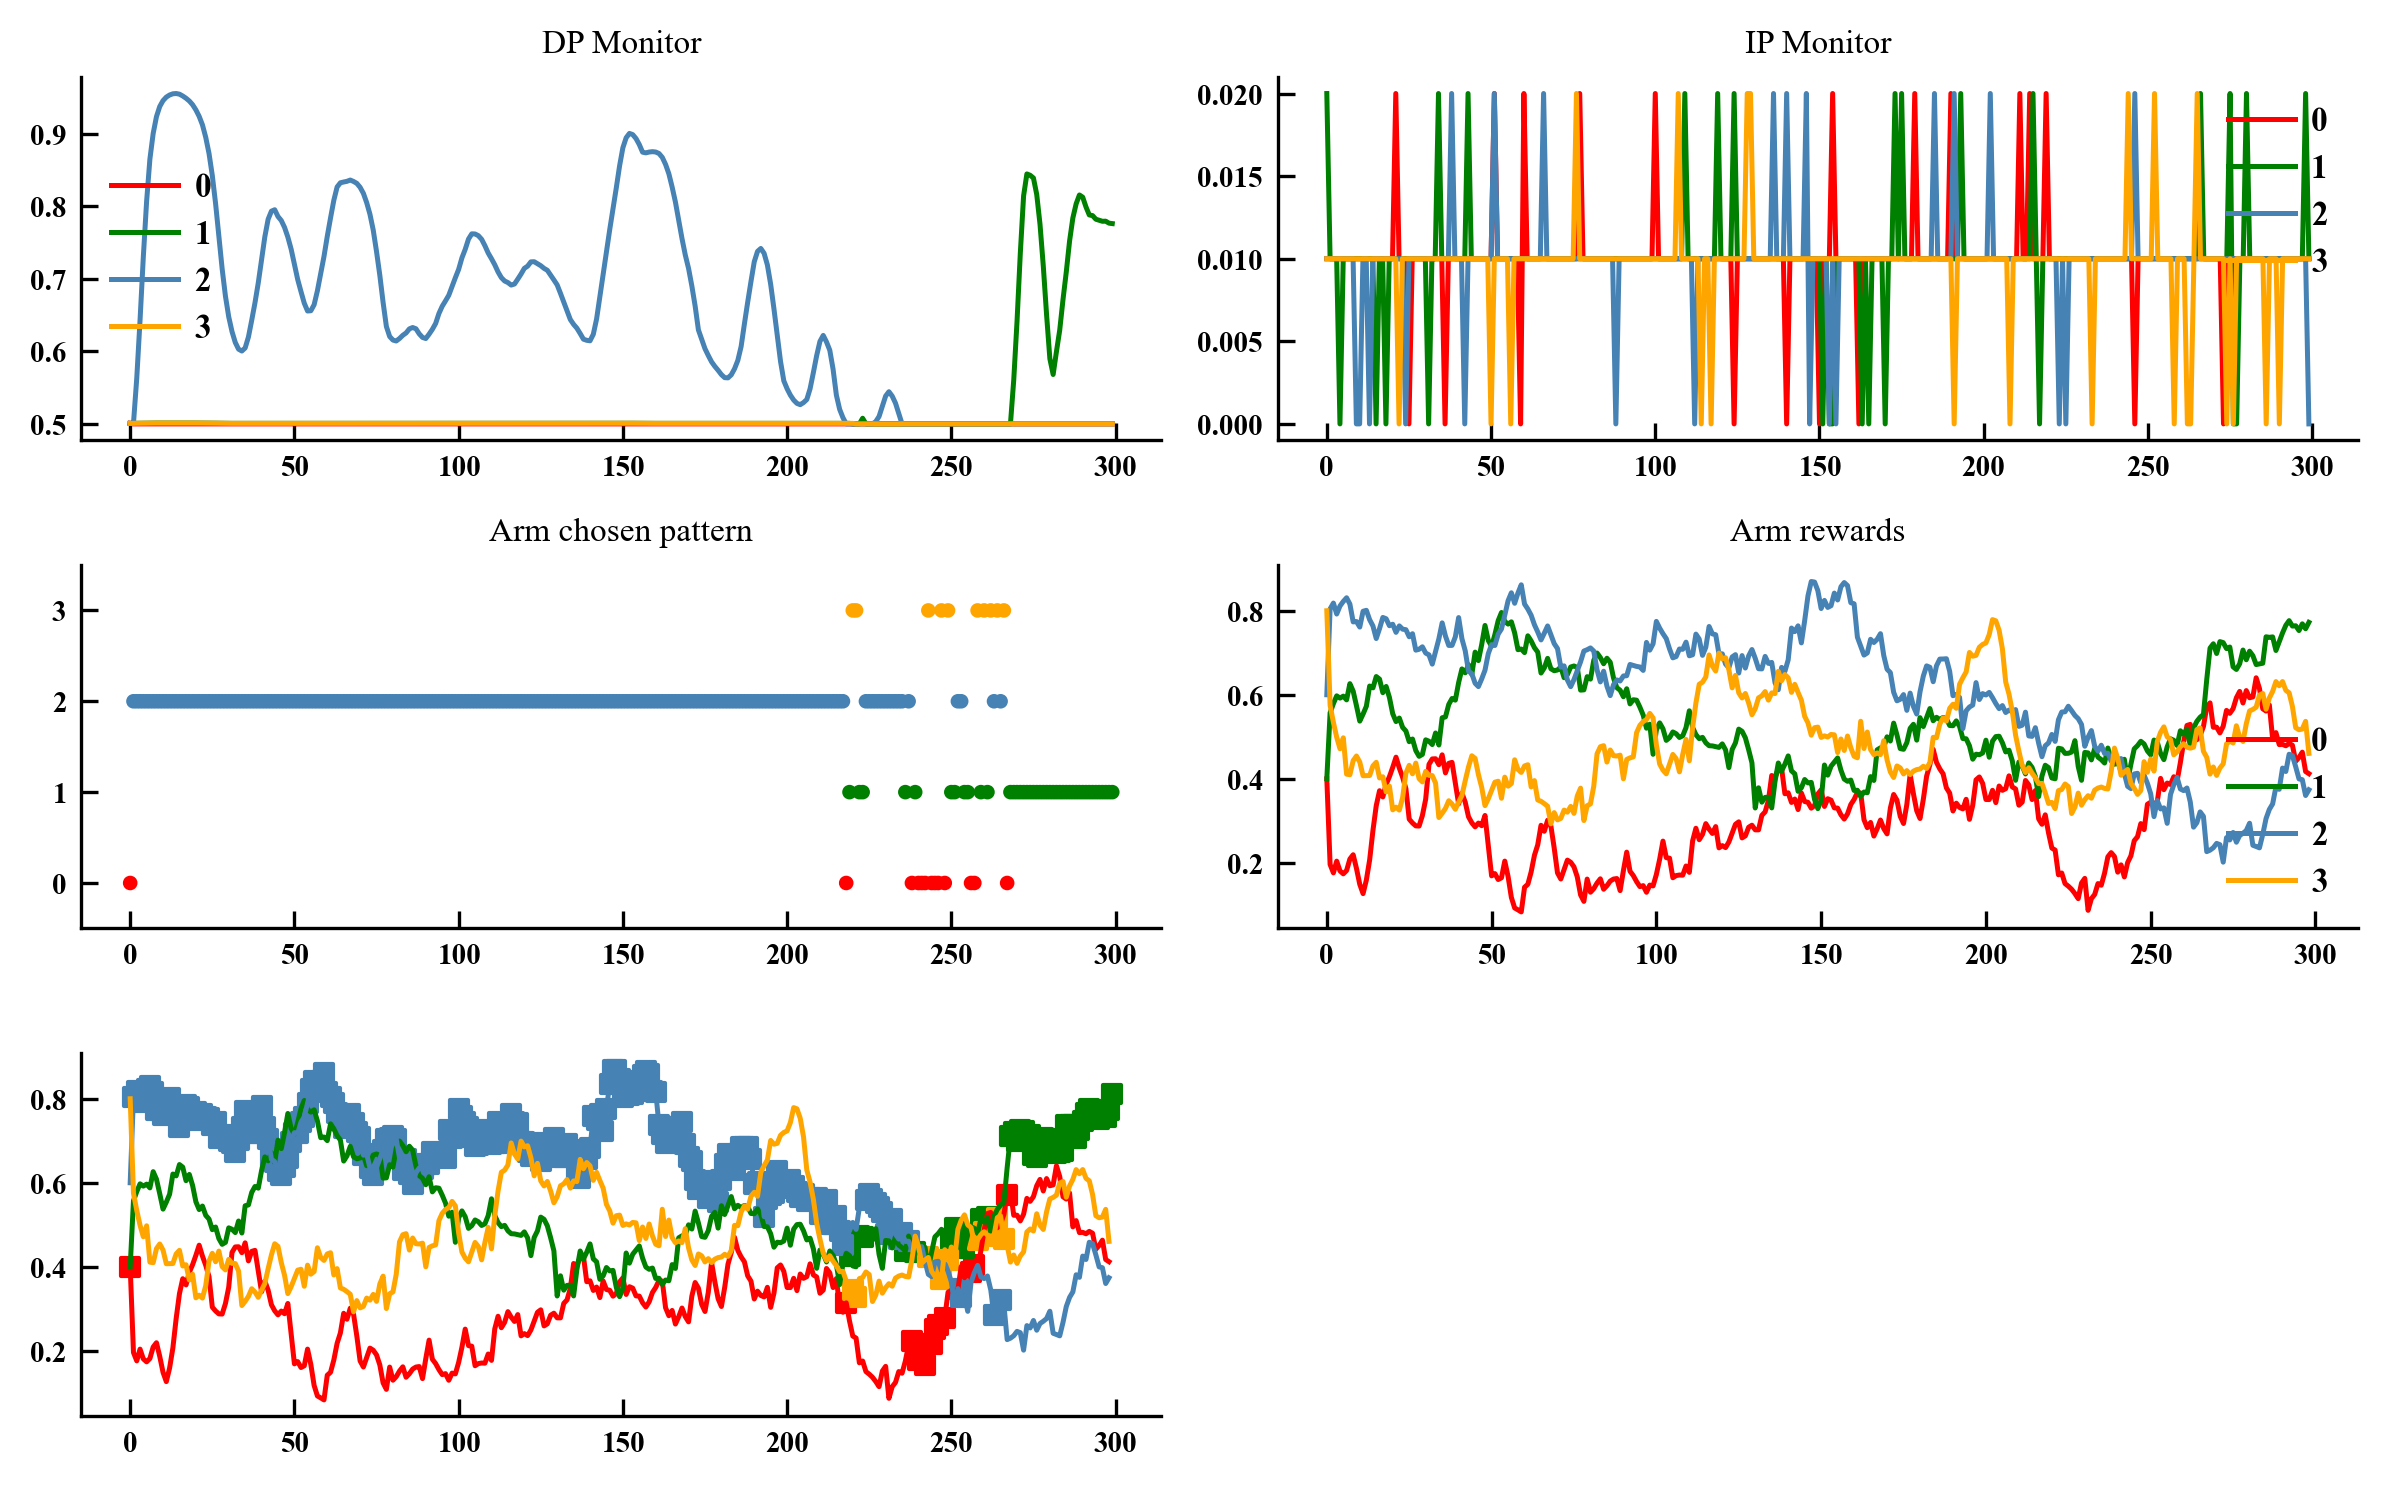

In [51]:
ARM_MONITOR[var] = arm_chosen_monitor
REWARD_MONITOR[var] = reward_monitor
DP_MONITOR[var] = dp_monitor
IP_MONITOR[var] = ip_monitor
ARM_TRACKER[var] = arm_tracker_full


EPOCH_NUM = 2
# color_map = {0: 'lightsteelblue', 1: 'cornflowerblue', 2: 'royalblue', 3: 'deepskyblue'}
color_map = {0: 'Red', 1: 'green', 2: 'steelblue', 3: 'orange'}
plt.figure(figsize=(8,5))
plt.subplot(321)
for i in range(NUM_ARMS):
    plt.plot(DP_MONITOR[var][i][EPOCH_NUM].squeeze().detach().numpy(), color = color_map[i], label = i)
    plt.legend()  
plt.title('DP Monitor')
plt.subplot(322)
for i in range(NUM_ARMS):
    plt.plot(IP_MONITOR[var][i][EPOCH_NUM].squeeze().detach().numpy(), color = color_map[i], label = i)
    plt.legend() 
plt.title('IP Monitor')

plt.subplot(323)
values = ARM_MONITOR[var][EPOCH_NUM]
color_array = np.vectorize(color_map.get)(values)
plt.scatter(np.arange(TRAILS),values, marker = '.', color = color_array)
plt.ylim(-0.5,3.5)
plt.title('Arm chosen pattern')

plt.subplot(324)
arm_means = ARM_TRACKER[var][EPOCH_NUM]
REW_ARRAY = np.zeros((NUM_ARMS, len(arm_means)))
for i in range(len(arm_means)):
    arms = arm_means[i]
    rews = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])
    REW_ARRAY[:,i] = rews
for i in range(NUM_ARMS):
    plt.plot(REW_ARRAY[i][0:-2], color = color_map[i], label = i)
plt.title('Arm rewards')
plt.legend()


plt.subplot(325)
MODIFIED_REW_ARRAY = np.zeros((NUM_ARMS,TRAILS))
for i in range(TRAILS):
    arm = int(ARM_MONITOR[var][EPOCH_NUM][i].detach().numpy())
    MODIFIED_REW_ARRAY[arm,i] = REW_ARRAY[arm,i] 
for i in range(NUM_ARMS):
    plt.plot(REW_ARRAY[i][0:-2], color = color_map[i], label = i)

    non_zero_indices = MODIFIED_REW_ARRAY[i] !=0
    time = np.arange(TRAILS)
    filtered_time = time[non_zero_indices]
    filtered_rewards = MODIFIED_REW_ARRAY[i][non_zero_indices]
    plt.scatter(filtered_time,filtered_rewards, color = color_map[i], marker = 's', s = 20)
plt.tight_layout()

Text(0, 0.5, '$P(Best Arm)$')

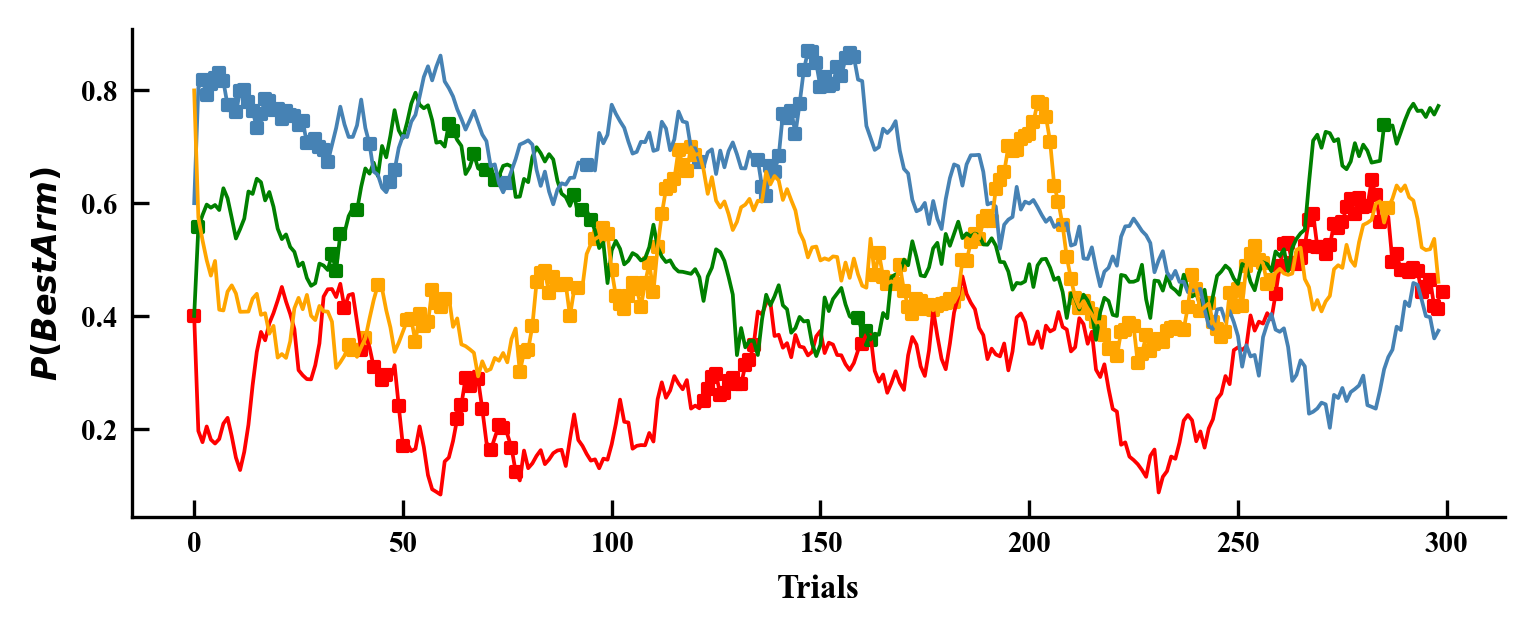

In [52]:
color_map = {0: 'Red', 1: 'green', 2: 'steelblue', 3: 'orange'}
EPOCH_NUM = 24
MODIFIED_REW_ARRAY = np.zeros((NUM_ARMS,TRAILS))
for i in range(TRAILS):
    arm = int(ARM_MONITOR[var][EPOCH_NUM][i].detach().numpy())
    MODIFIED_REW_ARRAY[arm,i] = REW_ARRAY[arm,i]

plt.figure(figsize = (5,2))    
for i in range(NUM_ARMS):
    plt.plot(REW_ARRAY[i][0:-2], color = color_map[i], label = i, linewidth = 0.9)

    non_zero_indices = MODIFIED_REW_ARRAY[i] !=0
    time = np.arange(TRAILS)
    filtered_time = time[non_zero_indices]
    filtered_rewards = MODIFIED_REW_ARRAY[i][non_zero_indices]
    plt.scatter(filtered_time,filtered_rewards, color = color_map[i], marker = 's', s = 5)
plt.xlabel('Trials')
plt.ylabel('$P(Best Arm)$')
# plt.title('Reward of the arm and choices of arm picking')

In [53]:
# Calculate average Prob of best arm picking every bin
def max_rew_arm(x:dict):
    rew_list = np.array([x[key][0] for key in list(x.keys())])
    return np.argmax(rew_list)

def process_epoch_optimal_arm(x:list):
    optimal_arm = [max_rew_arm(x[trail]) for trail in range(len(x)-1)]
    return optimal_arm

In [54]:
OPTIMAL_CHOICE_ARRAY = np.array([process_epoch_optimal_arm(ARM_TRACKER[var][epoch]) for epoch in range(len(ARM_TRACKER[var]))])
ACTUAL_CHOICE_ARRAY = np.array(ARM_MONITOR[var])
NUMBER_OF_MATCHES = (OPTIMAL_CHOICE_ARRAY == ACTUAL_CHOICE_ARRAY)*1
PROB = np.mean(NUMBER_OF_MATCHES,axis = 1)
print(f'P(Best Arm) = {PROB}')
print(f'Average P(Best arm) = {np.mean(PROB)}')

P(Best Arm) = [0.57666667 0.63666667 0.75       0.59666667 0.66666667 0.50333333
 0.37333333 0.74       0.67       0.77       0.28       0.39333333
 0.48       0.55333333 0.71       0.77333333 0.70666667 0.50333333
 0.68333333 0.75333333 0.49333333 0.58333333 0.57       0.65666667
 0.65333333]
Average P(Best arm) = 0.6030666666666668


In [ ]:
# # saving pickle file for data

# data = {'arm_chosen_monitor': arm_chosen_monitor, 'reward_monitor': reward_monitor, 
#         'dp_monitor': dp_monitor, 'ip_monitor': ip_monitor, 'arm_tracker_full': arm_tracker_full,
#         'prob': PROB, 'mean_prob': np.round(np.mean(PROB))}

# with open("normal_data.pkl", "wb") as f:
#     pickle.dump(data, f)
